In [81]:
import os
from dotenv import load_dotenv

load_dotenv()
import os
import sys
import requests

In [82]:
from langchain_openai import ChatOpenAI
from openai import OpenAI
from langchain_core.tools import tool

In [83]:
sys.path.append(os.path.abspath(".."))

In [84]:
sys.path.append(os.path.abspath("../.."))

In [85]:
from src.config import get_settings
settings = get_settings()
fastapi_base_url = settings.BASE_URL

In [86]:
fastapi_base_url

'http://localhost:8000'

In [87]:
@tool
def check_health() -> dict:

    """
    Checks the health of the Power BI API.

    This function verifies whether the Power BI service is reachable and functioning correctly
    by attempting to retrieve an access token from the configured Power BI endpoint.
    If a valid token is successfully returned, the API is considered healthy.
    """
    try:
        response = requests.get(f"{settings.BASE_URL}/health",timeout=5)
        response.raise_for_status()
        return {"status": "healthy"}

    except requests.exceptions.RequestException as e:
        return {"status": "unhealthy", "message": str(e)}

In [88]:
check_health.invoke({})

{'status': 'healthy'}

In [91]:
@tool
def compare_workspaces() -> dict:

    """
    Compares Power BI workspaces between DEV and PROD environments.

    This function identifies dashboard reports that exist in the DEV workspace
    but are missing in the PROD workspace. It also returns the total number of
    reports present in both DEV and PROD for comparison.
    """
    settings = get_settings()

    try:
        url = f"{settings.BASE_URL}/comparison"
        response = requests.get(url, timeout=10)
        response.raise_for_status()

        return {"status": "success", "data": response.json()}

    except Exception as e:
        return {
            "status": "error",
            "message": str(e)
        }

In [92]:
compare_workspaces.invoke({})

{'status': 'success',
 'data': {'status': {'missing_in_prod': ['invoice-Dashboard'],
   'missing_in_dev': ['Sales-Dashboard'],
   'counts': {'dev_total': 1,
    'prod_total': 1,
    'missing_in_prod': 1,
    'missing_in_dev': 1}}}}

In [93]:
@tool
def recommend_dashboards(user_query: str,top_n: int = 3) -> dict:
    
    """
    Recommend the most relevant Power BI dashboards based on a user query.

    This function analyzes a natural language query and returns the top matching
    dashboards ranked by relevance.

    Args:
        user_query (str): A natural language query describing the desired analysis
            (e.g., "looking for analysis related to supply chain pillar").
        top_n (int): The number of top dashboard recommendations to return.
    """
    settings = get_settings()

    try:
        url = f"{settings.BASE_URL}/recommend"
        params = {
            "user_query": user_query,
            "top_n": top_n
        }

        response = requests.get(url, params=params, timeout=15)
        response.raise_for_status()

        return {"status": "success", "data": response.json()}

    except Exception as e:
        return {
            "status": "error",
            "message": str(e)
        }

In [94]:
recommend_dashboards.invoke({
    "user_query": "looking for analysis related to supply chain pillar",
    "top_n": 3
})

{'status': 'success',
 'data': {'dashboards': [{'Selected_Dashboard': 'Purchase-Dashboard',
    'Reason': "The Purchase-Dashboard is highly relevant as it focuses on the purchase and inventory aspects of the supply chain, which are critical components of supply chain analysis. Its objective and domain align well with the user's requirement for supply chain analysis."},
   {'Selected_Dashboard': 'Sales-Dashboard',
    'Reason': 'The Sales-Dashboard is also relevant as it includes supply chain as a tag and provides insights into sales performance, which is an integral part of the supply chain process. It complements the purchase analysis by providing a view of the downstream effects on sales and revenue.'}]}}

In [95]:
@tool
def migrate_dashboard(
    dashboard_name: str,
    from_workspace_name: str,
    to_workspace_name: str
) -> dict:
    """
    Migrate a Power BI dashboard between workspaces.

    This function transfers a specified dashboard from a source workspace
    to a target workspace, typically used for promoting content from
    development (DEV) to production (PROD).

    Args:
        dashboard_name (str): Name of the dashboard to be migrated.
        from_workspace_name (str): Source workspace name (e.g., "DEV").
        to_workspace_name (str): Target workspace name (e.g., "PROD").

    Note:
        This operation should only be executed after explicit user confirmation,
        as it may impact production environments.
    """
    settings = get_settings()

    try:
        url = f"{settings.BASE_URL}/migration"

        params = {
            "dashboard_name": dashboard_name,
            "from_workspace_name": from_workspace_name,
            "to_workspace_name": to_workspace_name
        }

        response = requests.get(url, params=params, timeout=60)
        response.raise_for_status()

        return {
            "status": "success",
            "data": response.json()
        }

    except Exception as e:
        return {
            "status": "error",
            "message": str(e)
        }

In [98]:
migrate_dashboard.invoke({
    "dashboard_name": "Sales-Dashboard",
    "from_workspace_name": "Prod",
    "to_workspace_name": "Dev"
})

{'status': 'success',
 'data': {'dataset_id': 'fe1fb504-6bc7-482b-bf80-65a506f9b63c',
  'report_id': 'e69a4644-352e-44fa-b76f-3307a34ad0a3',
  'status': 'Sucess'}}

In [99]:
@tool
def delete_dashboard(
    dashboard_name: str,
    workspace_name: str
) -> dict:
    """
    Deletes a Power BI dashboard and its dataset from a workspace.

    Args:
        dashboard_name: Name of the dashboard to delete
        workspace_name: Workspace where the dashboard exists

    ⚠️ WARNING: This action is irreversible. Use only after user confirmation.
    """
    settings = get_settings()

    try:
        url = f"{settings.BASE_URL}/deletion"

        params = {
            "dashboard_name": dashboard_name,
            "workspace_name": workspace_name
        }

        response = requests.get(url, params=params, timeout=30)
        response.raise_for_status()

        return {
            "status": "success",
            "data": response.json()
        }

    except Exception as e:
        return {
            "status": "error",
            "message": str(e)
        }

In [100]:
delete_dashboard.invoke({
    "dashboard_name": "Sales-Dashboard",
    "workspace_name": "Prod"
})

{'status': 'success',
 'data': {'status': 'success',
  'message': 'Report and dataset deleted successfully',
  'resource_id': '15fe8b1c-55af-44e1-9c25-c4a2709ccb67',
  'Dashboard_name': 'Sales-Dashboard'}}

Now we will create agent for this tool

In [101]:
from langchain_core.messages import HumanMessage,SystemMessage,AIMessage
from langgraph.graph import StateGraph,START,END,MessagesState
from langgraph.prebuilt import ToolNode

In [102]:
from langgraph.prebuilt import ToolNode,tools_condition
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [132]:
from typing import List,Literal,Optional

In [195]:
llm = ChatOpenAI(model = settings.openai_llm_model)

In [196]:
tools = [check_health,recommend_dashboards,migrate_dashboard,delete_dashboard,compare_workspaces]
tool_node = ToolNode(tools)

In [ ]:
system_prompt = """
You are a helpful assistant specialized in Power BI operations.

Your capabilities include:
- Recommending Power BI dashboards based on user queries
- Migrating dashboards between workspaces (Dev → Prod)
- Deleting dashboards from Dev and Prod workspaces
- Comparing dashboards between Dev and Prod workspaces

Workspace Rules:
- Valid workspace names are "Dev" and "Prod"
- Normalize any user input (e.g., DEV, dev, PROD, prod) to "Dev" or "Prod"

Tool Usage Guidelines:
- Select the most appropriate tool based on the user’s intent
- Ensure actions like migration or deletion are clearly understood before execution

Clarification Handling:
- If the user query is unclear, ask up to 3 relevant clarifying questions
- If the intent is still unclear after clarification, respond with:
  "Sorry, not able to understand."

General Behavior:
- Be precise, structured, and action-oriented
- Do not assume missing details—always confirm when required

"""


In [198]:
system_message = SystemMessage(content=system_prompt)

In [199]:
from typing import List,Optional,Dict,Any
from pydantic import BaseModel

In [345]:
class AgentState(MessagesState):
    user_query: Optional[str]
    intent: Optional[str]
    clarification_count: int = 0
    is_confirmed: bool = False
    dashboard_name: Optional[str] = None
    source_workspace: Optional[str] = None
    target_workspace: Optional[str] = None
    

In [301]:
def agent_state_node(state: AgentState) -> Dict[str, Any]:
    messages = state["messages"]

    # Extract last human message safely
    user_query = None
    for msg in reversed(messages):
        if isinstance(msg, HumanMessage):
            user_query = msg.content
            break

    return {
        "messages": messages,
        "user_query": user_query,
        "intent": state.get("intent"),
        "clarification_count": state.get("clarification_count", 0),
        "is_confirmed": state.get("is_confirmed", None)
    }

In [349]:
class IntentOutput(BaseModel):
    intent: Literal[
        "recommend_dashboards",
        "compare_workspaces",
        "migrate_dashboard",
        "delete_dashboard",
        "ambiguous"
    ]
    
class InputSchema(BaseModel):
    dashboard_name: Optional[str] = None
    source_workspace: Optional[str] = None
    target_workspace: Optional[str] = None

In [303]:
def clarification_node(state: AgentState):
    count = state.get("clarification_count", 0)

    # Stop after 3 attempts
    if count >= 3:
        return {
            "messages": state["messages"] + [
                AIMessage(content="Sorry, not able to understand.")
            ]
        }

    llm = ChatOpenAI(model=settings.openai_llm_model)

    prompt = ChatPromptTemplate.from_messages([
        ("""You help clarify user intent for Power BI actions.

            Your goal is to ask ONE neutral and clear question to understand the user's intent.

            Guidelines:
            - Do NOT assume the user's intent
            - Do NOT suggest actions like migrate or delete unless explicitly mentioned
            - Offer clear choices instead of leading the user
            - Keep the question simple and specific
            ("human", "{question}")
            """
        )
    ])

    chain = prompt | llm | StrOutputParser()

    clarification_question = chain.invoke({
        "messages": state["user_query"]   # 🔥 FULL CONTEXT
    })

    return {
        "messages": state["messages"] + [
            AIMessage(content=clarification_question)
        ],
        "clarification_count": count + 1
    }

In [304]:
def confirmation_handler(state: AgentState):
    last_msg = state["messages"][-1].content.lower()

    if last_msg in ["yes", "y"]:
        return {
            "is_confirmed": True
        }
    elif last_msg in ["no", "n"]:
        return {
            "messages": state["messages"] + [
                AIMessage(content="❌ Operation cancelled.")
            ],
            "is_confirmed": False
        }
    else:
        return {
            "messages": state["messages"] + [
                AIMessage(content="Please reply with 'yes' or 'no'.")
            ]
        }

In [305]:
router_prompt = """
You are an expert AI agent that classifies user intent for Power BI operations.

Your task is to understand the user's goal and classify it into ONE of the following intents:

1. recommend_dashboards  
   → User is looking for suggestions, insights, or relevant dashboards based on a topic

2. compare_workspaces  
   → User wants to understand differences, gaps, discrepancies, or missing dashboards 
     between Dev and Prod workspaces

3. migrate_dashboard  
   → User wants to move, promote, or deploy a dashboard from one workspace (Dev) to another (Prod)

4. delete_dashboard  
   → User wants to remove or delete a dashboard from a workspace

5. ambiguous  
   → The user intent is unclear, incomplete, or cannot be confidently mapped

---

Guidelines:
- Focus on the USER'S GOAL, not keywords
- Use the full conversation context
- If the user replies with short answers like "yes", "ok", infer intent from previous messages
- Prefer compare_workspaces when the user is asking about differences, gaps, or missing items
- Only select migrate_dashboard or delete_dashboard if the user clearly intends an ACTION
- If unsure → return "ambiguous"
- Do NOT ask questions
- Do NOT explain

Return only the intent.
"""

In [306]:
def router_decision(state: AgentState):
    llm = ChatOpenAI(model=settings.openai_llm_model)

    prompt = ChatPromptTemplate.from_messages([
        ("system", router_prompt),
        ("placeholder", "{messages}")   # 🔥 CRITICAL
    ])


    chain = prompt | llm.with_structured_output(IntentOutput)

    response = chain.invoke({"messages": state["messages"]})

    return {
        "intent": response.intent
    }

In [307]:
def route_selector(state: AgentState):
    return state["intent"]

In [399]:
def confirmation_node(state: AgentState):
    dashboard = state.get("dashboard_name")
    source = state.get("source_workspace")
    target = state.get("target_workspace")
    intent = state.get("intent")


    if intent=="migrate_dashboard":

        # If still missing → ask again
        if not all([dashboard, source, target]):
            return {
                "messages": state["messages"] + [
                    AIMessage(content="""
                ⚠️ Missing required details.

                Please provide:
                dashboard_name, source_workspace, target_workspace

                Example:
                invoice-dashboard, dev, prod
                """)
                            ]
                        }

        return {
            "messages": state["messages"] + [
                AIMessage(content=f"""
            ⚠️ You are about to MIGRATE a dashboard.

            Details:
            - Dashboard: {dashboard}
            - From: {source}
            - To: {target}

            👉 Please confirm to proceed (yes/no)
            """.strip())
                    ]
                }
    else:
        if not all([dashboard, target]):
            return {
                "messages": state["messages"] + [
                    AIMessage(content="""
                ⚠️ Missing required details.

                Please provide:
                dashboard_name, target_workspace

                Example:
                invoice-dashboard, Prod
                """)
                            ]
                        }
        return {
            "messages": state["messages"] + [
                AIMessage(content=f"""
            ⚠️ You are about to Delete a dashboard.

            Details:
            - Dashboard: {dashboard}
            - From: {target}

            👉 Please confirm to proceed (yes/no)
            """.strip())
                    ]
                }



In [417]:
def parse_migration_input(state: AgentState):
    last_msg = state["messages"][-1].content.strip()

    intent = state["intent"]

    # Try parsing input
    parts = [p.strip() for p in last_msg.split(",")]

    if intent=="migrate_dashboard":


        if len(parts) == 3:
            return {
                "dashboard_name": parts[0],
                "source_workspace": parts[1],
                "target_workspace": parts[2]
            }

        # ❌ If not proper input → ASK USER
        return {
            "messages": state["messages"] + [
                AIMessage(content="""
                    Please provide the required details in this format:

                    dashboard_name, source_workspace, target_workspace

                    Example:
                    invoice-dashboard, dev, prod
                    """)
                            ]
                        }
    else:
        if len(parts)==2:
            return {
                "dashboard_name": parts[0],
                "target_workspace": parts[1]
            }
        return {"messages": state["messages"] + [
                AIMessage(content="""
                    Please provide the required details in this format:

                    dashboard_name, target_workspace

                    Example:
                    invoice-dashboard,prod
                    """)
                            ]
                        }



In [418]:
def entry_router(state: AgentState):
    last_msg = state["messages"][-1].content.lower().strip()

    # ✅ confirmation response
    if last_msg in ["yes", "no", "y", "n"]:
        return "confirmation"

    # ✅ input details (simple heuristic)
    if "," in last_msg:
        return "input"

    return "router"

In [419]:
def health_check_node(state: AgentState):
    result = check_health.invoke({}) 

    if result.get("status") != "healthy":
        return {
            "messages": state["messages"] + [
                AIMessage(content="❌ Power BI API is down. Aborting request.")
            ]
        }

    return state

In [ ]:
# class MigrationInput(BaseModel):
#     dashboard_name: Optional[str]
#     source_workspace: Optional[str]
#     target_workspace: Optional[str]

In [ ]:
# def get_previous_user_query(messages):
#     human_msgs = [m for m in messages if isinstance(m, HumanMessage)]

#     # If user just said "yes", take the previous message
#     if len(human_msgs) >= 2:
#         return human_msgs[-2].content

#     # fallback
#     return human_msgs[-1].content if human_msgs else None

In [ ]:
# def extract_migration_details(state: AgentState):
#     llm = ChatOpenAI(
#         model=settings.openai_llm_model,
#         temperature=0
#     )
#     query = get_previous_user_query(state["messages"])

#     prompt = ChatPromptTemplate.from_messages([
#         ("system", """
#             You extract migration details from user queries.

#             Extract:
#             - dashboard_name
#             - source_workspace
#             - target_workspace

#             Rules:
#             - Be precise
#             - If not found → return null
#             - Do NOT guess
#             """),
#                     ("human", "{query}")
#                 ])

#     chain = prompt | llm.with_structured_output(MigrationInput)

#     result = chain.invoke({
#         "query": query
#     })

#     return {
#         "dashboard_name": result.dashboard_name,
#         "source_workspace": result.source_workspace,
#         "target_workspace": result.target_workspace
#     }

In [431]:
def tool_executor(state: AgentState):
    """
    Based on the User Intent, execute the appropriate tool
    """
    intent = state["intent"]
    query = state["user_query"]

    if intent == "recommend_dashboards":
        result = recommend_dashboards.invoke({
            "user_query": query,
            "top_n": 3
        })

    elif intent == "compare_workspaces":
        result = compare_workspaces.invoke({})

    elif intent == "migrate_dashboard":
        dashboard = state.get("dashboard_name")
        source = state.get("source_workspace")
        target = state.get("target_workspace")
        if not all([dashboard, source, target]):
            return {
                "messages": state["messages"] + [
                    AIMessage(content="⚠️ Missing details. Please specify dashboard, source, and target.")
                ]
            }

        result = migrate_dashboard.invoke({
            "dashboard_name": dashboard,
            "workspace_name": source,
            "to_workspace_name": target
        })

    elif intent == "delete_dashboard":
        dashboard = state.get("dashboard_name")
        target = state.get("target_workspace")
        if not all([dashboard,target]):
            return {
                "messages": state["messages"] + [
                    AIMessage(content="⚠️ Missing details. Please specify dashboard and target workspace.")
                ]
            }

        result = delete_dashboard.invoke({
            "dashboard_name": dashboard,
            "workspace_name": target
        })

    else:
        return {
            "messages": state["messages"] + [
                AIMessage(content="Sorry, not able to understand.")
            ]
        }

    return {
        "messages": state["messages"] + [
            AIMessage(content=str(result))
        ]
    }

In [432]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [433]:
graph = StateGraph(AgentState)

graph.add_node("Question_Receiver", agent_state_node)
graph.add_node("Router", router_decision)
graph.add_node("Clarification", clarification_node)
graph.add_node("InputParser", parse_migration_input)
graph.add_node("Confirmation", confirmation_node)
graph.add_node("ConfirmationHandler", confirmation_handler)
graph.add_node("HealthCheck", health_check_node)
graph.add_node("ToolExecutor", tool_executor)

# ENTRY
graph.add_edge(START, "Question_Receiver")

graph.add_conditional_edges(
    "Question_Receiver",
    entry_router,
    {
        "router": "Router",
        "confirmation": "ConfirmationHandler",
        "input": "InputParser"
    }
)


# ROUTER
graph.add_conditional_edges(
    "Router",
    route_selector,
    {
        "recommend_dashboards": "HealthCheck",
        "compare_workspaces": "HealthCheck",
        "migrate_dashboard": "InputParser",   # ✅ FIXED
        "delete_dashboard": "InputParser",
        "ambiguous": "Clarification"
    }
)

# CLARIFICATION
graph.add_conditional_edges(
    "Clarification",
    lambda state: "end" if state.get("clarification_count", 0) >= 3 else "continue",
    {
        "continue": "Router",
        "end": END
    }
)

# INPUT → CONFIRM
graph.add_edge("InputParser", "Confirmation")

# CONFIRM → HANDLE
graph.add_edge("Confirmation", "ConfirmationHandler")

graph.add_conditional_edges(
    "ConfirmationHandler",
    lambda state: "proceed" if state.get("is_confirmed") else "end",
    {
        "proceed": "HealthCheck",
        "end": END
    }
)

# EXECUTION
graph.add_edge("HealthCheck", "ToolExecutor")
graph.add_edge("ToolExecutor", END)

# COMPILE
agent = graph.compile(
    checkpointer=memory,
    interrupt_after=["Confirmation"]  # ✅ now valid
)

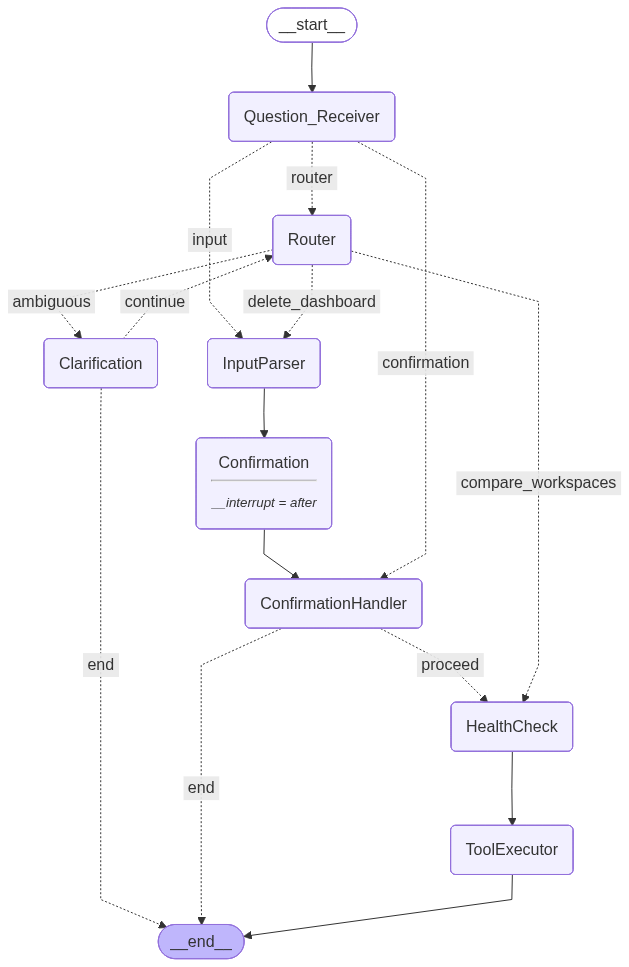

In [434]:
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [435]:
thread = {"configurable": {"thread_id": "999"}}

In [387]:
response = agent.invoke(
    {
        "messages": [
            HumanMessage(
                content="I need to understand is there any gap in dashboard available in dev and prod workspaces."
            )
        ]
    },
    config=thread
)

print(response["messages"][-1].content)

{'status': 'success', 'data': {'status': {'missing_in_prod': [], 'missing_in_dev': [], 'counts': {'dev_total': 2, 'prod_total': 2, 'missing_in_prod': 0, 'missing_in_dev': 0}}}}


In [382]:
thread = {"configurable": {"thread_id": "8866"}}

In [383]:
response = agent.invoke(
    {
        "messages": [
            HumanMessage(
                content="I need to push Sales-dashboard from dev to prod"
            )
        ]
    },
    config=thread
)

print(response["messages"][-1].content)


            ⚠️ Missing required details.

            Please provide:
            dashboard_name, source_workspace, target_workspace

            Example:
            invoice-dashboard, dev, prod
            


In [384]:
response = agent.invoke(
    {
        "messages": [
            HumanMessage(
                content="Sales-Dashboard, Dev, Prod"
            )
        ]
    },
    config=thread
)

print(response["messages"][-1].content)

⚠️ You are about to MIGRATE a dashboard.

        Details:
        - Dashboard: Sales-Dashboard
        - From: Dev
        - To: Prod

        👉 Please confirm to proceed (yes/no)


In [385]:
response = agent.invoke(
    {
        "messages": [
            HumanMessage(
                content="yes"
            )
        ]
    },
    config=thread
)

print(response["messages"][-1].content)

{'status': 'success', 'data': {'dataset_id': '9eff4933-6a11-4d53-a7c0-77181e368550', 'report_id': '1152ce15-3d89-4dbc-9588-da0014dff9b4', 'status': 'Sucess'}}


In [436]:
thread = {"configurable": {"thread_id": "7725"}}

In [437]:
response = agent.invoke(
    {
        "messages": [
            HumanMessage(
                content="I need to delete a dashboard from prod"
            )
        ]
    },
    config=thread
)

print(response["messages"][-1].content)


                ⚠️ Missing required details.

                Please provide:
                dashboard_name, target_workspace

                Example:
                invoice-dashboard, Prod
                


In [438]:
response = agent.invoke(
    {
        "messages": [
            HumanMessage(
                content="Sales-Dashboard,Prod"
            )
        ]
    },
    config=thread
)

print(response["messages"][-1].content)

⚠️ You are about to Delete a dashboard.

            Details:
            - Dashboard: Sales-Dashboard
            - From: Prod

            👉 Please confirm to proceed (yes/no)


In [439]:
response = agent.invoke(
    {
        "messages": [
            HumanMessage(
                content="yes"
            )
        ]
    },
    config=thread
)

print(response["messages"][-1].content)

{'status': 'success', 'data': {'status': 'success', 'message': 'Report and dataset deleted successfully', 'resource_id': '1152ce15-3d89-4dbc-9588-da0014dff9b4', 'Dashboard_name': 'Sales-Dashboard'}}


In [440]:
thread = {"configurable": {"thread_id": "8000"}}

In [441]:
response = agent.invoke(
    {
        "messages": [
            HumanMessage(
                content="looking for analaysis related to supply chain pillar"
            )
        ]
    },
    config=thread
)

print(response["messages"][-1].content)

{'status': 'success', 'data': {'dashboards': [{'Selected_Dashboard': 'Purchase-Dashboard', 'Reason': 'The Purchase Dashboard is directly related to the supply chain pillar as it focuses on purchases and inventory, which are critical components of the supply chain. Its objective and tags clearly align with supply chain analysis.'}, {'Selected_Dashboard': 'Sales-Dashboard', 'Reason': "The Sales Dashboard, while primarily focused on sales and revenue, includes supply chain as a tag and can provide insights into the supply chain's impact on sales performance. It is relevant for understanding the broader supply chain context."}]}}
